<a href="https://colab.research.google.com/github/Parker-P-Wilson/Linear-regression/blob/Tuan-3/Lab_3_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


bai 1


In [ ]:
# Bài 1: Load CIFAR-10 dataset
from keras.datasets import cifar10

cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

(X_train_c10, y_train_c10), (X_test_c10, y_test_c10) = cifar10.load_data()

print('X_train shape:', X_train_c10.shape)  # (50000, 32, 32, 3)
print('X_test shape:', X_test_c10.shape)    # (10000, 32, 32, 3)
print('y_train shape:', y_train_c10.shape)
print('y_test shape:', y_test_c10.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000, 1)
y_test shape: (10000, 1)


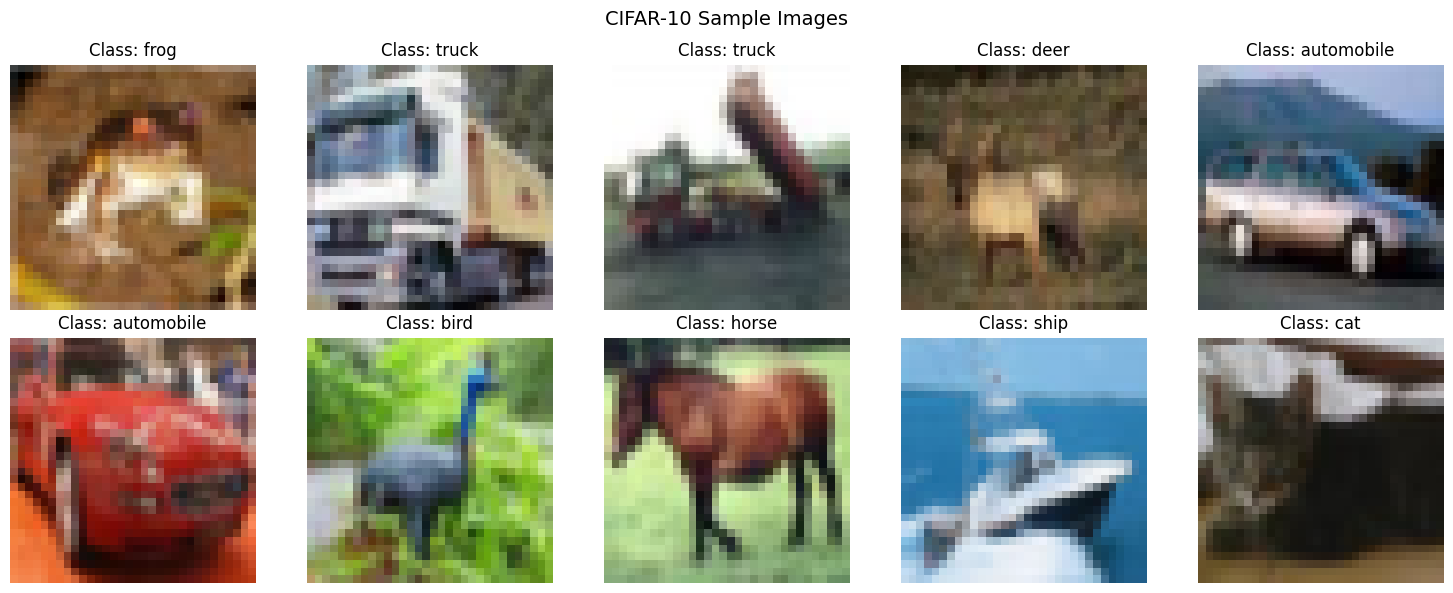

In [ ]:
# Trực quan hóa một số ảnh CIFAR-10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_c10[i])
    axes[i].set_title('Class: ' + cifar10_labels[y_train_c10[i][0]])
    axes[i].axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý dữ liệu CIFAR-10
# Reshape từ (N, 32, 32, 3) sang (N, 3072)
X_train_c10_flat = X_train_c10.reshape(X_train_c10.shape[0], -1).astype('float32')
X_test_c10_flat  = X_test_c10.reshape(X_test_c10.shape[0], -1).astype('float32')

# Feature scaling: normalize pixel values to [0, 1]
X_train_c10_flat = X_train_c10_flat / 255.0
X_test_c10_flat  = X_test_c10_flat  / 255.0

# Flatten labels
y_train_c10_flat = y_train_c10.flatten()
y_test_c10_flat  = y_test_c10.flatten()

print('X_train_flat shape:', X_train_c10_flat.shape)
print('X_test_flat shape:', X_test_c10_flat.shape)

X_train_flat shape: (50000, 3072)
X_test_flat shape: (10000, 3072)


In [ ]:
# Xây dựng mô hình ANN cho CIFAR-10
cifar10_model = Sequential()

# Hidden layer 1
cifar10_model.add(Dense(units=512, input_dim=X_train_c10_flat.shape[1],
                        kernel_initializer='uniform', activation='relu'))
cifar10_model.add(Dropout(0.3))

# Hidden layer 2
cifar10_model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))
cifar10_model.add(Dropout(0.3))

# Hidden layer 3
cifar10_model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Output layer: 10 classes
cifar10_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Compile
cifar10_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

cifar10_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình CIFAR-10
cifar10_fit = cifar10_model.fit(
    X_train_c10_flat, y_train_c10_flat,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    verbose=1
)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.2720 - loss: 1.9660 - val_accuracy: 0.3426 - val_loss: 1.8163
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.3422 - loss: 1.8142 - val_accuracy: 0.3734 - val_loss: 1.7420
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3671 - loss: 1.7604 - val_accuracy: 0.3828 - val_loss: 1.7213
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.3769 - loss: 1.7211 - val_accuracy: 0.4090 - val_loss: 1.6669
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.3907 - loss: 1.6961 - val_accuracy: 0.4258 - val_loss: 1.6076
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.4009 - loss: 1.6629 - val_accuracy: 0.4254 - val_loss: 1.6009
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.4097 - loss: 1.6428 - val_accuracy: 0.4402 - val_loss: 1.5758
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.4145 - loss: 1.6270 - 

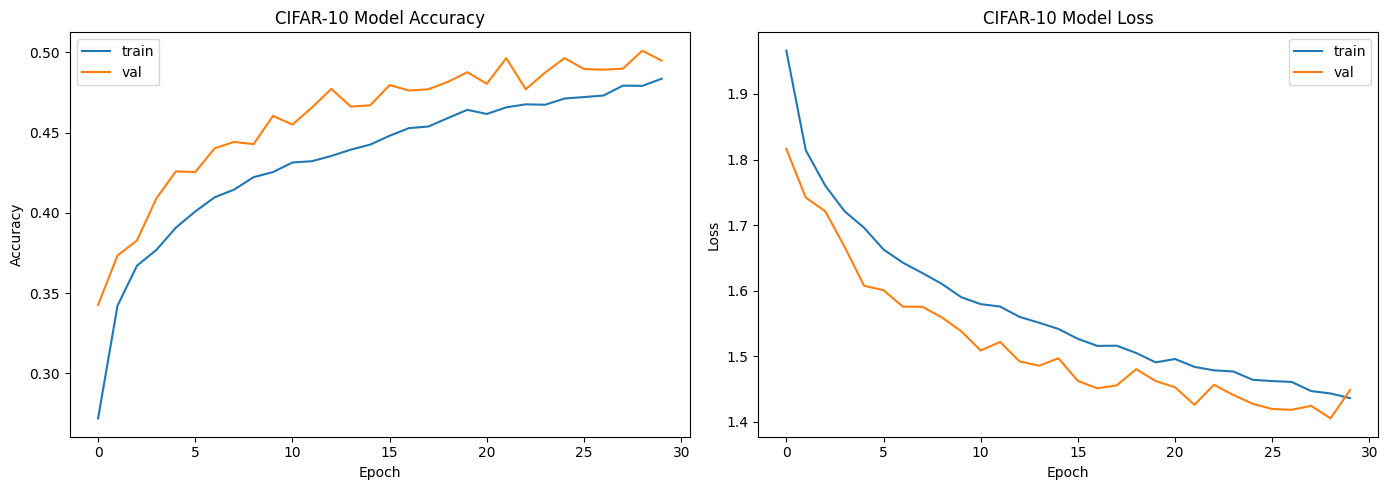


Test Accuracy: 0.4885
Test Loss: 1.4499


In [ ]:
# Đánh giá mô hình CIFAR-10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cifar10_fit.history['accuracy'], label='train')
axes[0].plot(cifar10_fit.history['val_accuracy'], label='val')
axes[0].set_title('CIFAR-10 Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(cifar10_fit.history['loss'], label='train')
axes[1].plot(cifar10_fit.history['val_loss'], label='val')
axes[1].set_title('CIFAR-10 Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Test accuracy
test_loss, test_acc = cifar10_model.evaluate(X_test_c10_flat, y_test_c10_flat, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


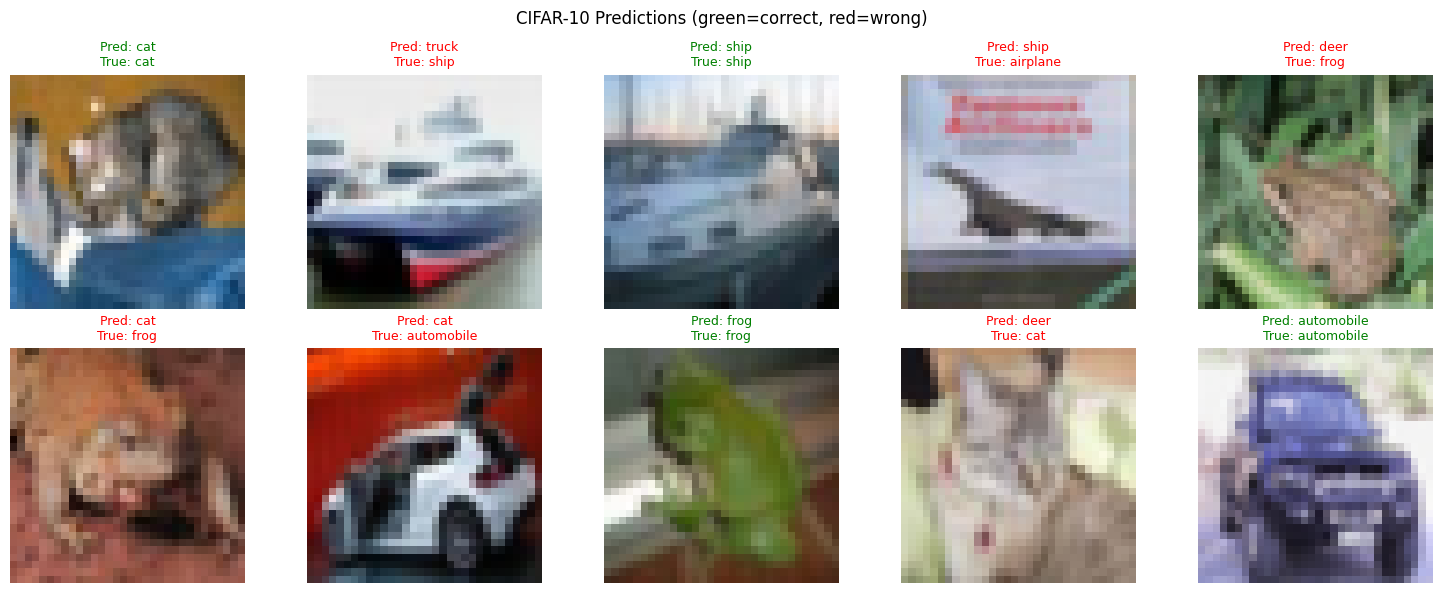

In [ ]:
# Dự báo ảnh mới từ tập test
y_pred_c10 = np.argmax(cifar10_model.predict(X_test_c10_flat), axis=1)

# Hiển thị một số kết quả dự báo
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_test_c10[i])
    pred_label = cifar10_labels[y_pred_c10[i]]
    true_label = cifar10_labels[y_test_c10_flat[i]]
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {pred_label}\nTrue: {true_label}', color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

bai 2

In [ ]:
# Bài 2: Load MNIST dataset (built-in Keras)
from keras.datasets import mnist

(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

print('X_train shape:', X_train_mnist.shape)  # (60000, 28, 28)
print('X_test shape:', X_test_mnist.shape)    # (10000, 28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)


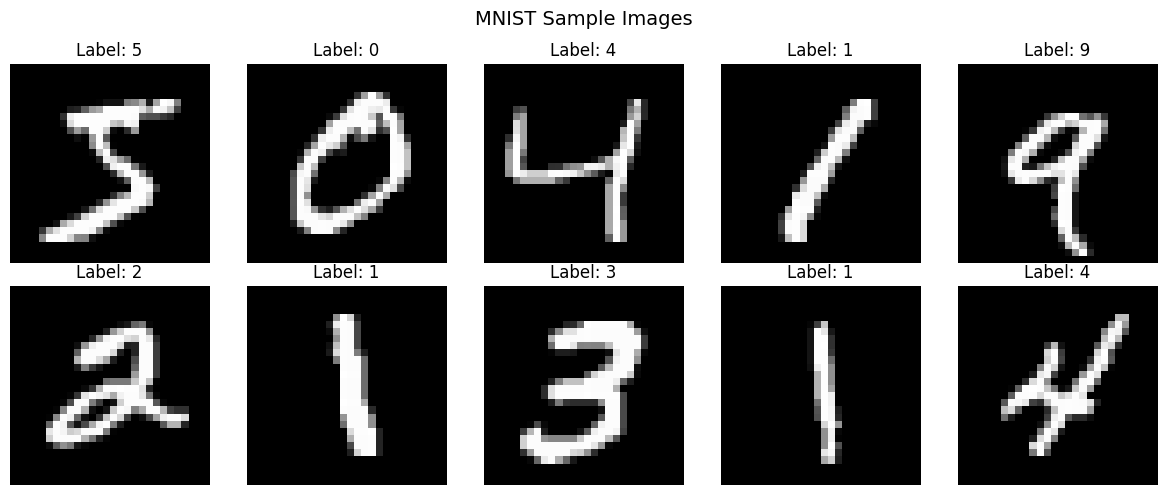

In [ ]:
# Trực quan hóa MNIST
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_mnist[i], cmap='gray')
    axes[i].set_title('Label: ' + str(y_train_mnist[i]))
    axes[i].axis('off')
plt.suptitle('MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý dữ liệu MNIST
# Reshape (N, 28, 28) -> (N, 784)
X_train_mnist_flat = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_mnist_flat  = X_test_mnist.reshape(10000, 784).astype('float32')  / 255.0

print('X_train_flat shape:', X_train_mnist_flat.shape)
print('Classes:', np.unique(y_train_mnist))

X_train_flat shape: (60000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Xây dựng mô hình ANN cho MNIST
mnist_model = Sequential()

mnist_model.add(Dense(units=256, input_dim=784,
                      kernel_initializer='uniform', activation='relu'))
mnist_model.add(Dropout(0.2))

mnist_model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Output: 10 chữ số
mnist_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

mnist_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

mnist_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện MNIST
mnist_fit = mnist_model.fit(
    X_train_mnist_flat, y_train_mnist,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8807 - loss: 0.4230 - val_accuracy: 0.9585 - val_loss: 0.1490
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9510 - loss: 0.1656 - val_accuracy: 0.9720 - val_loss: 0.0955
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9653 - loss: 0.1161 - val_accuracy: 0.9752 - val_loss: 0.0861
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9738 - loss: 0.0867 - val_accuracy: 0.9757 - val_loss: 0.0803
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9771 - loss: 0.0721 - val_accuracy: 0.9768 - val_loss: 0.0744
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9814 - loss: 0.0582 - val_accuracy: 0.9793 - val_loss: 0.0818
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9845 - loss: 0.0492 - val_accuracy: 0.9822 - val_loss: 0.0669
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9862 - loss: 0.0438 - val_accurac

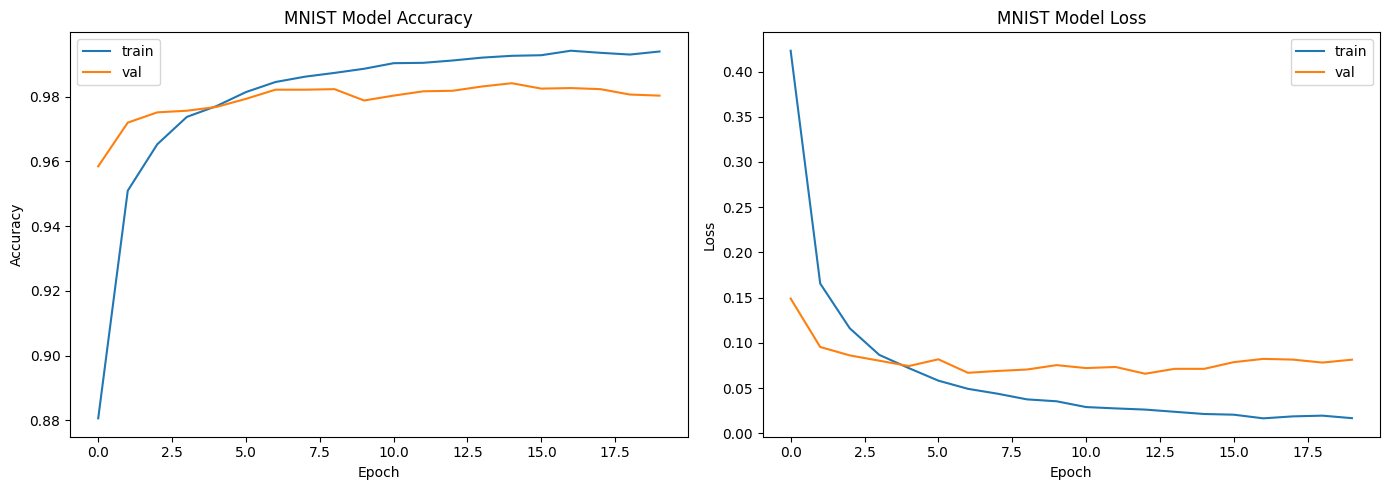


Test Accuracy: 0.9790
Test Loss: 0.0894


In [ ]:
# Đánh giá mô hình MNIST
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mnist_fit.history['accuracy'], label='train')
axes[0].plot(mnist_fit.history['val_accuracy'], label='val')
axes[0].set_title('MNIST Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(mnist_fit.history['loss'], label='train')
axes[1].plot(mnist_fit.history['val_loss'], label='val')
axes[1].set_title('MNIST Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = mnist_model.evaluate(X_test_mnist_flat, y_test_mnist, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


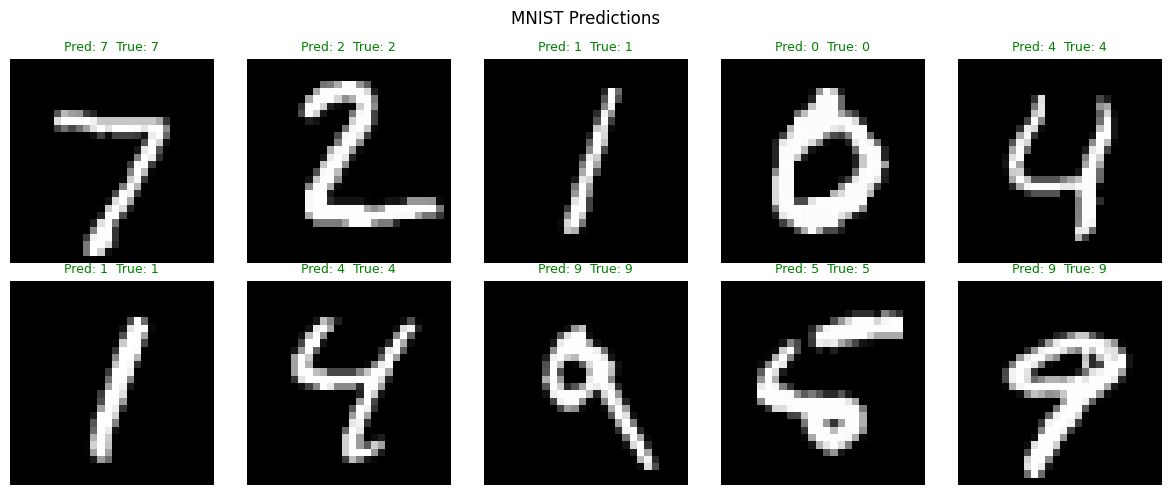

In [ ]:
# Dự báo ảnh MNIST
y_pred_mnist = np.argmax(mnist_model.predict(X_test_mnist_flat), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_test_mnist[i], cmap='gray')
    pred = y_pred_mnist[i]
    true = y_test_mnist[i]
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'Pred: {pred}  True: {true}', color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('MNIST Predictions', fontsize=12)
plt.tight_layout()
plt.show()


bai 3

In [ ]:
# Cài Kaggle API
!pip install kaggle

# Đặt file kaggle.json vào ~/.kaggle/
# (Tải từ Kaggle > Account > Create API Token)

# Download dataset
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset
!unzip microsoft-catsvsdogs-dataset.zip -d data/

Streaming output truncated to the last 5000 lines.
  inflating: data/PetImages/Dog/550.jpg  
  inflating: data/PetImages/Dog/5500.jpg  
  inflating: data/PetImages/Dog/5501.jpg  
  inflating: data/PetImages/Dog/5502.jpg  
  inflating: data/PetImages/Dog/5503.jpg  
  inflating: data/PetImages/Dog/5504.jpg  
  inflating: data/PetImages/Dog/5505.jpg  
  inflating: data/PetImages/Dog/5506.jpg  
  inflating: data/PetImages/Dog/5507.jpg  
  inflating: data/PetImages/Dog/5508.jpg  
  inflating: data/PetImages/Dog/5509.jpg  
  inflating: data/PetImages/Dog/551.jpg  
  inflating: data/PetImages/Dog/5510.jpg  
  inflating: data/PetImages/Dog/5511.jpg  
  inflating: data/PetImages/Dog/5512.jpg  
  inflating: data/PetImages/Dog/5513.jpg  
  inflating: data/PetImages/Dog/5514.jpg  
  inflating: data/PetImages/Dog/5515.jpg  
  inflating: data/PetImages/Dog/5516.jpg  
  inflating: data/PetImages/Dog/5517.jpg  
  inflating: data/PetImages/Dog/5518.jpg  
  inflating: data/PetImages/Dog/5519.jpg  
  inf

In [ ]:
# Bài 3: Load dữ liệu Cat vs Dog
import os
from numpy import asarray, save, load
from keras.preprocessing.image import load_img, img_to_array



# =====================================================
# Thay đổi đường dẫn phù hợp với dữ liệu của bạn
folder = 'train/'   # Thư mục chứa ảnh cat*.jpg và dog*.jpg
IMG_SIZE = (200, 200)
# =====================================================

photos, labels = [], []

if os.path.exists(folder):
    for file in os.listdir(folder):
        output = 0.0  # cat
        if file.startswith('dog'):
            output = 1.0
        photo = load_img(os.path.join(folder, file), target_size=IMG_SIZE)
        photo = img_to_array(photo)
        photos.append(photo)
        labels.append(output)

    photos = asarray(photos)
    labels = asarray(labels)
    print('Photos shape:', photos.shape)
    print('Labels shape:', labels.shape)

    # Lưu ra file .npy
    save('dogs_vs_cats_photos.npy', photos)
    save('dogs_vs_cats_labels.npy', labels)
    print('Saved to .npy files.')
else:
    print(f"Thư mục '{folder}' không tồn tại. Vui lòng cung cấp dữ liệu.")
    # Demo: tạo dữ liệu giả để test pipeline
    photos = np.random.rand(20, 200, 200, 3).astype('float32')
    labels = np.array([0]*10 + [1]*10, dtype='float32')
    print('Sử dụng dữ liệu giả để demo pipeline.')

Thư mục 'train/' không tồn tại. Vui lòng cung cấp dữ liệu.
Sử dụng dữ liệu giả để demo pipeline.


In [ ]:
# Xử lý dữ liệu Cat vs Dog
n_samples = photos.shape[0]
X_catdog = photos.reshape(n_samples, -1).astype('float32') / 255.0
y_catdog = labels.astype('int32')

# Train/test split
from sklearn.model_selection import train_test_split
X_train_cd, X_test_cd, y_train_cd, y_test_cd = train_test_split(
    X_catdog, y_catdog, test_size=0.2, random_state=42
)

print('X_train shape:', X_train_cd.shape)
print('X_test shape:', X_test_cd.shape)

X_train shape: (16, 120000)
X_test shape: (4, 120000)


In [ ]:
# Xây dựng mô hình ANN Cat vs Dog
catdog_model = Sequential()

catdog_model.add(Dense(units=512, input_dim=X_train_cd.shape[1],
                       kernel_initializer='uniform', activation='relu'))
catdog_model.add(Dropout(0.4))

catdog_model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))
catdog_model.add(Dropout(0.3))

catdog_model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Output: 2 class (cat=0, dog=1) -> dùng sigmoid cho binary
catdog_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

catdog_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

catdog_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │    61,440,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,604,865 (235.00 MB)

 Trainable params: 61,604,865 (235.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện Cat vs Dog
catdog_fit = catdog_model.fit(
    X_train_cd, y_train_cd,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.5714 - loss: 0.6932 - val_accuracy: 0.0000e+00 - val_loss: 0.6933
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5714 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6429 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5714 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7143 - loss: 0.6891 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7857 - loss: 0.6869 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9286 - loss: 0.6840 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 9/50
1

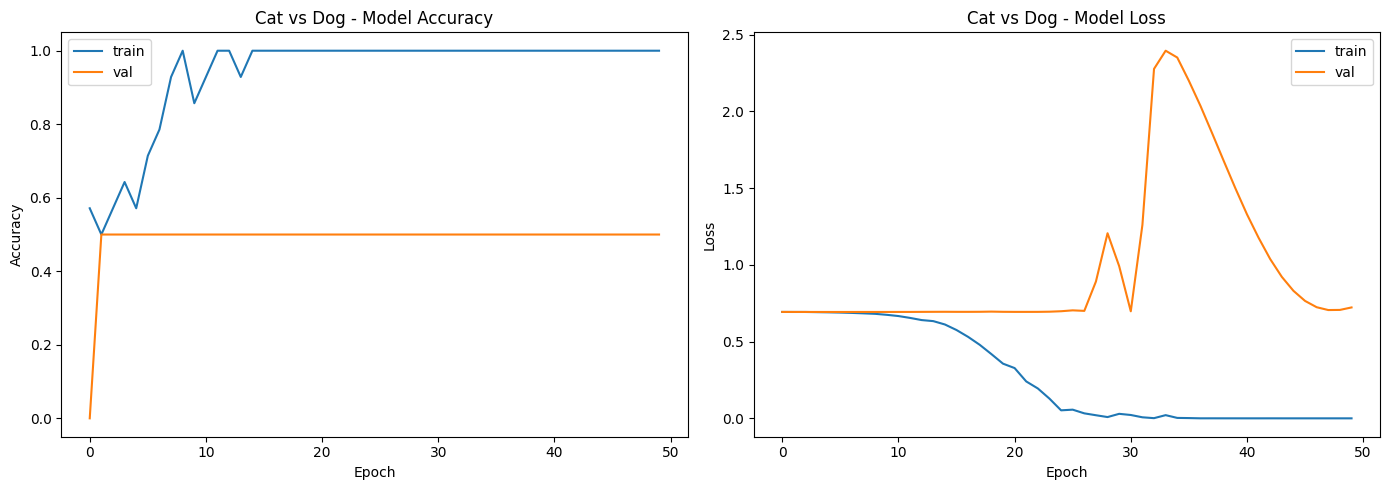


Test Accuracy: 0.5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

Classification Report:
              precision    recall  f1-score   support

         Cat       0.50      0.50      0.50         2
         Dog       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [ ]:
# Đánh giá mô hình Cat vs Dog
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(catdog_fit.history['accuracy'], label='train')
axes[0].plot(catdog_fit.history['val_accuracy'], label='val')
axes[0].set_title('Cat vs Dog - Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(catdog_fit.history['loss'], label='train')
axes[1].plot(catdog_fit.history['val_loss'], label='val')
axes[1].set_title('Cat vs Dog - Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = catdog_model.evaluate(X_test_cd, y_test_cd, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f}')

# Dự báo
y_pred_cd = (catdog_model.predict(X_test_cd) > 0.5).astype(int).flatten()
print('\nClassification Report:')
print(classification_report(y_test_cd, y_pred_cd, target_names=['Cat', 'Dog']))

bai 4

In [ ]:
# Bài 4: Load Adult dataset
# Thử load từ file trước, nếu không có thì dùng URL
adult_columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

try:
    adult_df = pd.read_csv('adult.csv')
    print('Loaded from adult.csv')
except FileNotFoundError:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
    adult_df = pd.read_csv(url, header=None, names=adult_columns,
                           sep=', ', engine='python', na_values='?')
    print('Loaded from UCI repository')

print(adult_df.head())
print('Shape:', adult_df.shape)

Loaded from UCI repository
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0

In [ ]:
# Xử lý dữ liệu Adult
# Xóa hàng thiếu dữ liệu
adult_df.dropna(inplace=True)

# Encode các cột categorical
from sklearn.preprocessing import LabelEncoder

adult_encoded = adult_df.copy()
le = LabelEncoder()
cat_cols = adult_encoded.select_dtypes(include='object').columns

for col in cat_cols:
    adult_encoded[col] = le.fit_transform(adult_encoded[col].astype(str))

print('Encoded columns:', list(cat_cols))
print(adult_encoded.head())

# Tách features và label
X_adult = adult_encoded.drop('income', axis=1).values
y_adult = adult_encoded['income'].values   # 0: <=50K, 1: >50K

# Scale features
scaler_adult = MinMaxScaler()
X_adult = scaler_adult.fit_transform(X_adult)

# Train/test split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42
)

print('X_train shape:', X_train_a.shape)
print('Classes:', np.unique(y_adult))

Encoded columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
   age  workclass  fnlwgt  education  education-num  marital-status  \
0   39          5   77516          9             13               4   
1   50          4   83311          9             13               2   
2   38          2  215646         11              9               0   
3   53          2  234721          1              7               2   
4   28          2  338409          9             13               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           0             1     4    1          2174             0   
1           3             0     4    1             0             0   
2           5             1     4    1             0             0   
3           5             0     2    1             0             0   
4           9             5     2    0             0             0   

   hours-per-week

In [ ]:
# Xây dựng mô hình ANN Adult
adult_model = Sequential()

adult_model.add(Dense(units=128, input_dim=X_train_a.shape[1],
                      kernel_initializer='uniform', activation='relu'))
adult_model.add(Dropout(0.3))

adult_model.add(Dense(units=64, kernel_initializer='uniform', activation='relu'))
adult_model.add(Dropout(0.2))

adult_model.add(Dense(units=32, kernel_initializer='uniform', activation='relu'))

# Output: binary classification
adult_model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

adult_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

adult_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện Adult model
adult_fit = adult_model.fit(
    X_train_a, y_train_a,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7655 - loss: 0.4970 - val_accuracy: 0.8148 - val_loss: 0.4107
Epoch 2/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8198 - loss: 0.3950 - val_accuracy: 0.8259 - val_loss: 0.3793
Epoch 3/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8265 - loss: 0.3656 - val_accuracy: 0.8276 - val_loss: 0.3438
Epoch 4/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8308 - loss: 0.3565 - val_accuracy: 0.8264 - val_loss: 0.3502
Epoch 5/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8331 - loss: 0.3511 - val_accuracy: 0.8371 - val_loss: 0.3404
Epoch 6/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8379 - loss: 0.3465 - val_accuracy: 0.8342 - val_loss: 0.3393
Epoch 7/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8382 - loss: 0.3468 - val_accuracy: 0.8313 - val_loss: 0.3437
Epoch 8/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8365 - loss: 0.3460 - val_accuracy: 0.

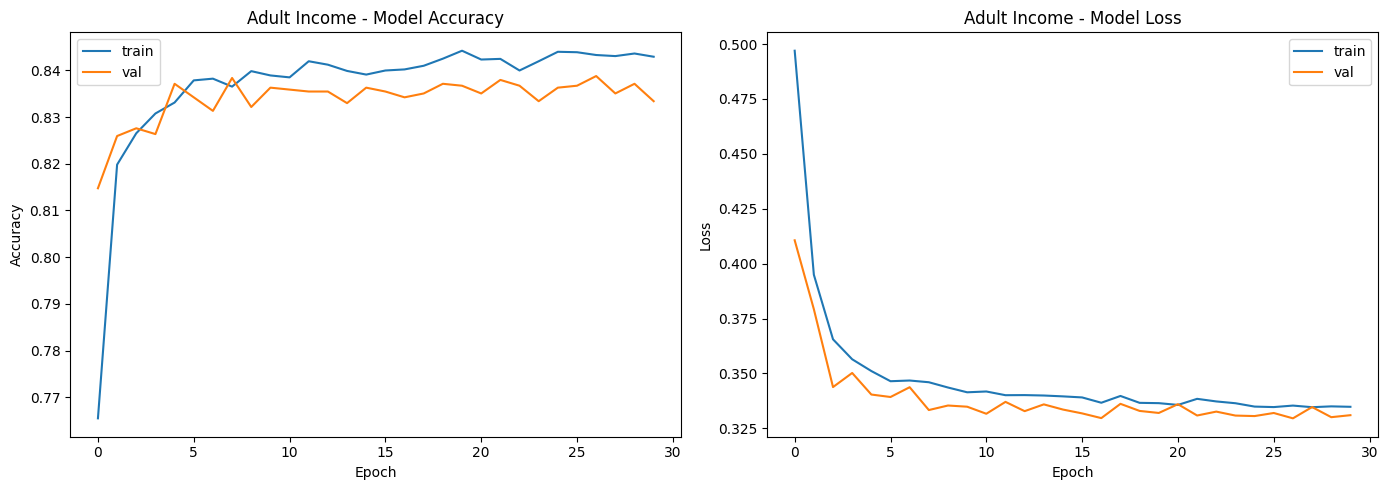


Test Accuracy: 0.8452
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.85      0.96      0.90      4503
        >50K       0.81      0.51      0.62      1530

    accuracy                           0.85      6033
   macro avg       0.83      0.73      0.76      6033
weighted avg       0.84      0.85      0.83      6033



In [ ]:
# Đánh giá Adult model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(adult_fit.history['accuracy'], label='train')
axes[0].plot(adult_fit.history['val_accuracy'], label='val')
axes[0].set_title('Adult Income - Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(adult_fit.history['loss'], label='train')
axes[1].plot(adult_fit.history['val_loss'], label='val')
axes[1].set_title('Adult Income - Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = adult_model.evaluate(X_test_a, y_test_a, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f}')

y_pred_a = (adult_model.predict(X_test_a) > 0.5).astype(int).flatten()
print('\nClassification Report:')
print(classification_report(y_test_a, y_pred_a, target_names=['<=50K', '>50K']))

bai 5

In [ ]:
# Bài 5: Load Car Evaluation dataset
car_columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

try:
    car_df = pd.read_csv('car.csv')
    print('Loaded from car.csv')
except FileNotFoundError:
    try:
        car_df = pd.read_csv('car.data', header=None, names=car_columns)
        print('Loaded from car.data')
    except FileNotFoundError:
        url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
        car_df = pd.read_csv(url, header=None, names=car_columns)
        print('Loaded from UCI repository')

print(car_df.head())
print('Shape:', car_df.shape)
print('\nClass distribution:')
print(car_df['class'].value_counts())

Loaded from UCI repository
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Shape: (1728, 7)

Class distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [ ]:
# Xử lý dữ liệu Car
car_encoded = car_df.copy()
le_car = LabelEncoder()

# Encode tất cả cột (bao gồm cả label)
for col in car_encoded.columns:
    car_encoded[col] = le_car.fit_transform(car_encoded[col].astype(str))

print(car_encoded.head())

X_car = car_encoded.drop('class', axis=1).values
y_car = car_encoded['class'].values

# Scale features
scaler_car = MinMaxScaler()
X_car = scaler_car.fit_transform(X_car)

n_classes_car = len(np.unique(y_car))
print('\nNumber of classes:', n_classes_car)
print('Classes:', np.unique(y_car))

# Train/test split
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car, y_car, test_size=0.2, random_state=42
)

print('X_train shape:', X_train_car.shape)

   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       2      2

Number of classes: 4
Classes: [0 1 2 3]
X_train shape: (1382, 6)


In [ ]:
# Xây dựng mô hình ANN Car Evaluation
car_model = Sequential()

car_model.add(Dense(units=64, input_dim=X_train_car.shape[1],
                    kernel_initializer='uniform', activation='relu'))
car_model.add(Dropout(0.2))

car_model.add(Dense(units=32, kernel_initializer='uniform', activation='relu'))

# Output: multi-class (4 classes: unacc, acc, good, vgood)
car_model.add(Dense(units=n_classes_car, kernel_initializer='uniform', activation='softmax'))

car_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

car_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện Car model
car_fit = car_model.fit(
    X_train_car, y_train_car,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8536 - loss: 0.3620 - val_accuracy: 0.7770 - val_loss: 0.4431
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8552 - loss: 0.3469 - val_accuracy: 0.8129 - val_loss: 0.4119
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8665 - loss: 0.3286 - val_accuracy: 0.7914 - val_loss: 0.4251
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8600 - loss: 0.3424 - val_accuracy: 0.8058 - val_loss: 0.4165
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8592 - loss: 0.3565 - val_accuracy: 0.8489 - val_loss: 0.3887
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8632 - loss: 0.3454 - val_accuracy: 0.8633 - val_loss: 0.3819
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8729 - loss: 0.3339 - val_accuracy: 0.8273 - val_loss: 0.3857
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8665 - loss: 0.3301 - val_accuracy: 0.8633 - 

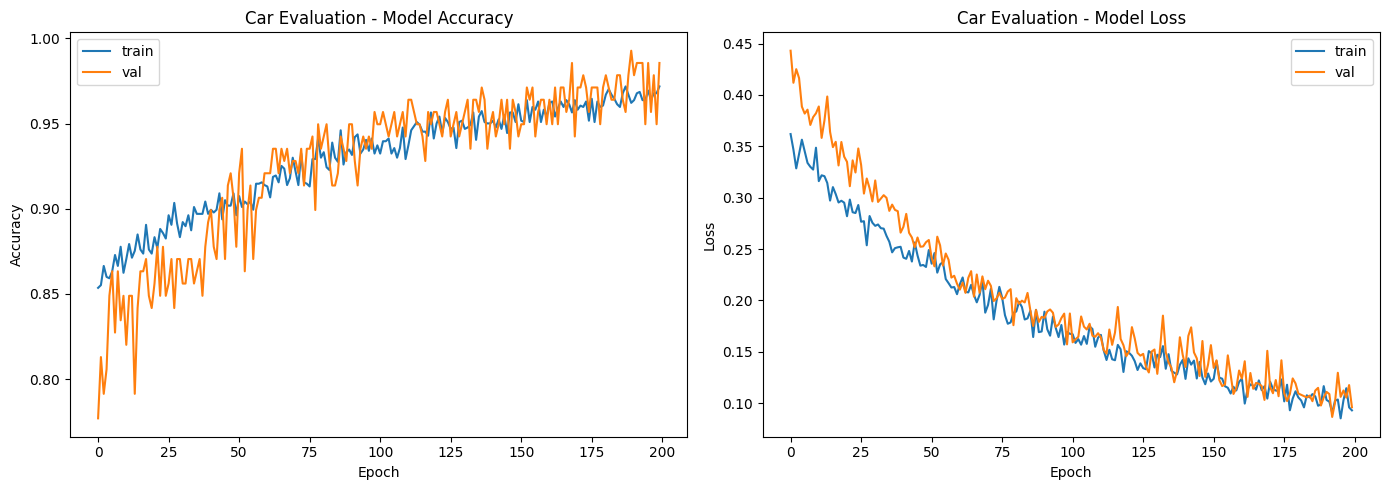


Test Accuracy: 0.9711
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        83
           1       0.67      0.91      0.77        11
           2       0.99      1.00      0.99       235
           3       1.00      0.82      0.90        17

    accuracy                           0.97       346
   macro avg       0.91      0.92      0.90       346
weighted avg       0.97      0.97      0.97       346



In [ ]:
# Đánh giá Car model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(car_fit.history['accuracy'], label='train')
axes[0].plot(car_fit.history['val_accuracy'], label='val')
axes[0].set_title('Car Evaluation - Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='upper left')

axes[1].plot(car_fit.history['loss'], label='train')
axes[1].plot(car_fit.history['val_loss'], label='val')
axes[1].set_title('Car Evaluation - Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = car_model.evaluate(X_test_car, y_test_car, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f}')

y_pred_car = np.argmax(car_model.predict(X_test_car), axis=1)
print('\nClassification Report:')
print(classification_report(y_test_car, y_pred_car))

bai 6`

In [ ]:
# Lưu mô hình MNIST để dùng trong Flask
mnist_model.save('mnist_model.h5')
print('Model saved to mnist_model.h5')

Model saved to mnist_model.h5


In [ ]:
# Tạo Flask app (app.py)
flask_app_code = '''
from flask import Flask, request, jsonify, render_template_string
import numpy as np
import tensorflow as tf
from keras.models import load_model
import base64
from PIL import Image
import io

app = Flask(__name__)

# Load mô hình đã huấn luyện
model = load_model('mnist_model.h5')

HTML_TEMPLATE = """
<!DOCTYPE html>
<html>
<head>
    <title>ANN - MNIST Digit Recognizer</title>
    <style>
        body { font-family: Arial; text-align: center; padding: 30px; background: #f0f4f8; }
        canvas { border: 3px solid #333; cursor: crosshair; background: black; }
        button { margin: 10px; padding: 10px 20px; font-size: 16px; cursor: pointer;
                 border-radius: 5px; border: none; }
        #predict-btn { background: #4CAF50; color: white; }
        #clear-btn   { background: #f44336; color: white; }
        #result { font-size: 24px; font-weight: bold; color: #333; margin-top: 20px; }
    </style>
</head>
<body>
    <h1>MNIST Digit Recognizer</h1>
    <p>Vẽ một chữ số (0-9) vào ô dưới đây:</p>
    <canvas id="canvas" width="280" height="280"></canvas><br>
    <button id="predict-btn" onclick="predict()">Nhận dạng</button>
    <button id="clear-btn" onclick="clearCanvas()">Xóa</button>
    <div id="result">Kết quả: --</div>
    <script>
        const canvas = document.getElementById('canvas');
        const ctx = canvas.getContext('2d');
        let drawing = false;
        ctx.fillStyle = 'black';
        ctx.fillRect(0, 0, 280, 280);
        canvas.onmousedown = e => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); };
        canvas.onmousemove = e => {
            if (!drawing) return;
            ctx.strokeStyle = 'white'; ctx.lineWidth = 15; ctx.lineCap = 'round';
            ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke();
        };
        canvas.onmouseup = () => drawing = false;
        function clearCanvas() {
            ctx.fillStyle = 'black'; ctx.fillRect(0, 0, 280, 280);
            document.getElementById('result').innerText = 'Kết quả: --';
        }
        function predict() {
            const imageData = canvas.toDataURL('image/png');
            fetch('/predict', { method: 'POST', headers: {'Content-Type': 'application/json'},
                body: JSON.stringify({ image: imageData }) })
            .then(r => r.json())
            .then(data => {
                document.getElementById('result').innerText =
                    'Kết quả: ' + data.digit + ' (confidence: ' + (data.confidence*100).toFixed(1) + '%)';
            });
        }
    </script>
</body>
</html>
"""

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    img_data = data['image'].split(',')[1]
    img_bytes = base64.b64decode(img_data)
    img = Image.open(io.BytesIO(img_bytes)).convert('L').resize((28, 28))
    img_array = np.array(img).reshape(1, 784).astype('float32') / 255.0
    prediction = model.predict(img_array)
    digit = int(np.argmax(prediction))
    confidence = float(np.max(prediction))
    return jsonify({'digit': digit, 'confidence': confidence})

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
'''

# Ghi ra file app.py
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(flask_app_code)

print('Flask app đã được tạo: app.py')
print('\nĐể chạy Flask app, thực thi lệnh sau trong terminal:')
print('  pip install flask pillow')
print('  python app.py')
print('\nSau đó truy cập: http://localhost:5000')

Flask app đã được tạo: app.py

Để chạy Flask app, thực thi lệnh sau trong terminal:
  pip install flask pillow
  python app.py

Sau đó truy cập: http://localhost:5000


In [ ]:
# Ghi chú: Chạy Flask trong Jupyter (chỉ dùng khi cần test nhanh trong notebook)
# Bỏ comment dòng dưới nếu muốn chạy trực tiếp từ notebook
# Lưu ý: Sẽ chặn cell cho đến khi dừng server (Ctrl+C)

# import subprocess
# subprocess.Popen(['python', 'app.py'])

print('Flask app sẵn sàng. Chạy: python app.py')

Flask app sẵn sàng. Chạy: python app.py
